# Scene Segmenter Training

This notebook is fully self-contained: all scene-segmentation training and visualization code is defined here.
Run the cells from top to bottom, then tune the configuration cell and rerun only the lower execution cells as needed.

In [1]:
from pathlib import Path
import os
import random
import time

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

PROJECT_ROOT = Path.cwd().resolve().parent
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAINING_ROOT = PROJECT_ROOT / "project" / "training_data"
SCENE_IMAGES_DIR = TRAINING_ROOT / "training_images" / "augmented_scenes"
SCENE_MASKS_DIR = TRAINING_ROOT / "training_masks" / "augmented_scenes"
MODELS_DIR = PROJECT_ROOT / "project" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

if not SCENE_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Scene images directory not found: {SCENE_IMAGES_DIR}")
if not SCENE_MASKS_DIR.exists():
    raise FileNotFoundError(f"Scene masks directory not found: {SCENE_MASKS_DIR}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Scene images: {SCENE_IMAGES_DIR}")
print(f"Scene masks: {SCENE_MASKS_DIR}")
print(f"Model output dir: {MODELS_DIR}")
print(f"torch: {torch.__version__}")
print(f"Device: {device}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Scene images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\augmented_scenes
Scene masks: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_masks\augmented_scenes
Model output dir: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models
torch: 2.11.0+cu128
Device: cuda


## Core Functions

The next cell defines the dataset, model, losses, metrics, and training helpers used in this notebook.

In [2]:
def letterbox(img, target_size=256, fill=255, interpolation=Image.BILINEAR):
    w, h = img.size
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    img = img.resize((new_w, new_h), interpolation)

    pad_w = target_size - new_w
    pad_h = target_size - new_h
    padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)

    return TF.pad(img, padding, fill=fill)


def preprocess_scene_pair(img_path, mask_path, image_size=256):
    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    img = letterbox(img, target_size=image_size, fill=255, interpolation=Image.BILINEAR)
    mask = letterbox(mask, target_size=image_size, fill=0, interpolation=Image.NEAREST)

    img_t = TF.to_tensor(img)
    img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    mask_arr = np.array(mask, dtype=np.float32) / 255.0
    mask_arr = (mask_arr > 0.5).astype(np.float32)
    mask_t = torch.from_numpy(mask_arr).unsqueeze(0)

    return img_t, mask_t


class SceneSegDataset(Dataset):
    def __init__(self, pairs, image_size=256, augment=False, cache_in_ram=True):
        self.pairs = pairs
        self.image_size = image_size
        self.augment = augment
        self.cache_in_ram = cache_in_ram
        self.cache = []

        if self.cache_in_ram:
            print(f"  Pre-loading {len(self.pairs)} samples into RAM...", flush=True)
            for i, (img_path, mask_path) in enumerate(self.pairs, start=1):
                self.cache.append(preprocess_scene_pair(img_path, mask_path, image_size=self.image_size))
                if i % 200 == 0 or i == len(self.pairs):
                    print(f"  {i}/{len(self.pairs)} loaded", flush=True)
            print("  Done.", flush=True)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        if self.cache_in_ram:
            img_t, mask_t = self.cache[idx]
        else:
            img_path, mask_path = self.pairs[idx]
            img_t, mask_t = preprocess_scene_pair(img_path, mask_path, image_size=self.image_size)

        if self.augment:
            if random.random() < 0.5:
                img_t = TF.hflip(img_t)
                mask_t = TF.hflip(mask_t)
            if random.random() < 0.5:
                img_t = TF.vflip(img_t)
                mask_t = TF.vflip(mask_t)

        return img_t, mask_t


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits).view(-1)
    targets = targets.view(-1)
    intersection = (probs * targets).sum()
    dice = (2.0 * intersection + eps) / (probs.sum() + targets.sum() + eps)
    return 1.0 - dice


def iou_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = ((preds + targets) > 0).float().sum(dim=(1, 2, 3))
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def format_seconds(seconds):
    minutes = int(seconds // 60)
    remaining_seconds = int(seconds % 60)
    return f"{minutes:02d}:{remaining_seconds:02d}"


def train_one_epoch(model, loader, optimizer, bce_loss, scaler, amp_enabled):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    seen = 0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(imgs)
            loss_bce = bce_loss(logits, masks)
            loss_dice = dice_loss_from_logits(logits, masks)
            loss = 0.5 * loss_bce + 0.5 * loss_dice

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size_now = imgs.size(0)
        running_loss += loss.item() * batch_size_now
        running_iou += iou_score_from_logits(logits.detach(), masks) * batch_size_now
        seen += batch_size_now

    return running_loss / seen, running_iou / seen, seen


@torch.no_grad()
def evaluate(model, loader, bce_loss, amp_enabled):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    seen = 0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(imgs)
            loss_bce = bce_loss(logits, masks)
            loss_dice = dice_loss_from_logits(logits, masks)
            loss = 0.5 * loss_bce + 0.5 * loss_dice

        batch_size_now = imgs.size(0)
        running_loss += loss.item() * batch_size_now
        running_iou += iou_score_from_logits(logits, masks) * batch_size_now
        seen += batch_size_now

    return running_loss / seen, running_iou / seen, seen


def denormalize_image(img_t):
    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img_np, 0, 1)

## Experiment Configuration And Execution

Tune hyperparameters below, then run the training and visualization cells.

In [3]:
# Data
image_size = 256
val_split = 0.15

# On Windows notebooks, multiprocessing workers can stall before batch 1.
# Keep cache enabled for speed, but run DataLoader in single-process mode.
is_windows = os.name == "nt"
cache_in_ram = True
num_workers = 0 if is_windows else min(4, os.cpu_count() or 1)

# Training
epochs = 30
batch_size = 8 if device.type == "cuda" else 4
learning_rate = 1e-3
weight_decay = 1e-4
use_amp = device.type == "cuda"
use_torch_compile = False
early_stopping_patience = 8
log_every_batches = 25

# Optional warm-start from a previous checkpoint (set True if you want to reuse it)
warm_start_from_card_segmenter = False
warm_start_checkpoint = MODELS_DIR / "segmenter_unet_small.pth"

# Output checkpoint
scene_checkpoint = MODELS_DIR / "scene_segmenter_unet_small.pth"

print(f"image_size={image_size}, batch_size={batch_size}, epochs={epochs}")
print(f"is_windows={is_windows}, cache_in_ram={cache_in_ram}, num_workers={num_workers}")
print(f"use_amp={use_amp}, warm_start={warm_start_from_card_segmenter}")
print(f"scene checkpoint: {scene_checkpoint}")
print(f"log_every_batches={log_every_batches}")

image_size=256, batch_size=8, epochs=30
is_windows=True, cache_in_ram=True, num_workers=0
use_amp=True, warm_start=False
scene checkpoint: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\scene_segmenter_unet_small.pth
log_every_batches=25


In [4]:
# Build (image, mask) pairs from generated augmented scenes
valid_img_ext = {".jpg", ".jpeg", ".png"}
valid_mask_ext = {".png", ".jpg", ".jpeg"}

# Index masks by stem so aug_scene_00001.jpg correctly pairs with aug_scene_00001.png
mask_by_stem = {}
for mask_path in sorted(SCENE_MASKS_DIR.iterdir()):
    if mask_path.suffix.lower() in valid_mask_ext:
        mask_by_stem[mask_path.stem] = mask_path

scene_pairs = []
missing_masks = []
for img_path in sorted(SCENE_IMAGES_DIR.iterdir()):
    if img_path.suffix.lower() not in valid_img_ext:
        continue

    mask_path = mask_by_stem.get(img_path.stem)
    if mask_path is not None and mask_path.is_file():
        scene_pairs.append((img_path, mask_path))
    else:
        missing_masks.append(img_path.name)

print(f"Total scene pairs: {len(scene_pairs)}")
if missing_masks:
    print(f"Images without matching mask: {len(missing_masks)}")
    print("First missing examples:", missing_masks[:5])

if len(scene_pairs) == 0:
    raise RuntimeError(
        "No augmented scene pairs found. Check training_images/augmented_scenes and "
        "training_masks/augmented_scenes."
        )

scene_train_pairs, scene_val_pairs = train_test_split(
    scene_pairs,
    test_size=val_split,
    random_state=SEED,
    shuffle=True,
    )

print(f"Train: {len(scene_train_pairs)} | Val: {len(scene_val_pairs)}")

Total scene pairs: 500
Train: 425 | Val: 75


In [5]:
train_ds = SceneSegDataset(
    scene_train_pairs,
    image_size=image_size,
    augment=True,
    cache_in_ram=cache_in_ram,
    )
val_ds = SceneSegDataset(
    scene_val_pairs,
    image_size=image_size,
    augment=False,
    cache_in_ram=cache_in_ram,
    )

effective_num_workers = num_workers
if cache_in_ram and effective_num_workers > 0:
    print("[info] cache_in_ram=True with num_workers>0 can stall on Windows; forcing num_workers=0")
    effective_num_workers = 0

loader_kwargs = dict(
    batch_size=batch_size,
    num_workers=effective_num_workers,
    pin_memory=device.type == "cuda",
    )
if effective_num_workers > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)

print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Loader workers in use: {effective_num_workers}")

  Pre-loading 425 samples into RAM...
  200/425 loaded
  400/425 loaded
  425/425 loaded
  Done.
  Pre-loading 75 samples into RAM...
  75/75 loaded
  Done.
Train samples: 425 | Val samples: 75
Train batches: 54 | Val batches: 10
Loader workers in use: 0


In [6]:
model = UNetSmall().to(device)
channels_last = device.type == "cuda"

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    model = model.to(memory_format=torch.channels_last)
else:
    print("[warning] CUDA not available. Training can be significantly slower on CPU.")

if warm_start_from_card_segmenter and warm_start_checkpoint.is_file():
    state_dict = torch.load(warm_start_checkpoint, map_location=device)
    model.load_state_dict(state_dict, strict=False)
    print(f"Loaded warm-start checkpoint: {warm_start_checkpoint}")
elif warm_start_from_card_segmenter:
    print("[info] Warm-start checkpoint not found. Training from scratch.")

if use_torch_compile and hasattr(torch, "compile"):
    model = torch.compile(model)
    print("torch.compile enabled")

n_params = count_trainable_params(model)
assert n_params <= 12_000_000, f"Model has {n_params:,} params, exceeds 12M cap"
print(f"[compliance] UNetSmall: {n_params:,} trainable params")

bce_loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    )

if device.type == "cuda":
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
else:
    scaler = None

print(f"Initial LR: {optimizer.param_groups[0]['lr']:.2e}")

[compliance] UNetSmall: 1,928,417 trainable params
Initial LR: 1.00e-03


In [7]:
def train_one_epoch_verbose(
    model,
    loader,
    optimizer,
    bce_loss,
    scaler,
    amp_enabled,
    log_every=25,
    channels_last=False,
    ):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    seen = 0
    num_batches = len(loader)
    loop_start = time.perf_counter()

    for batch_idx, (imgs, masks) in enumerate(loader, start=1):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        if channels_last:
            imgs = imgs.contiguous(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(imgs)
            loss_bce = bce_loss(logits, masks)
            loss_dice = dice_loss_from_logits(logits, masks)
            loss = 0.5 * loss_bce + 0.5 * loss_dice

        if scaler is not None and amp_enabled:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size_now = imgs.size(0)
        running_loss += loss.item() * batch_size_now
        running_iou += iou_score_from_logits(logits.detach(), masks) * batch_size_now
        seen += batch_size_now

        if log_every and (batch_idx == 1 or batch_idx % log_every == 0 or batch_idx == num_batches):
            elapsed = time.perf_counter() - loop_start
            avg_batch_seconds = elapsed / batch_idx
            eta_seconds = avg_batch_seconds * (num_batches - batch_idx)
            avg_loss = running_loss / max(seen, 1)
            avg_iou = running_iou / max(seen, 1)
            print(
                f"    batch {batch_idx:03d}/{num_batches:03d} | "
                f"avg_loss={avg_loss:.4f} avg_iou={avg_iou:.4f} | "
                f"eta={format_seconds(eta_seconds)}",
                flush=True,
                )

    return running_loss / max(seen, 1), running_iou / max(seen, 1), seen

In [8]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
    "lr": [],
    "epoch_seconds": [],
    "train_seconds": [],
    "val_seconds": [],
    "images_per_sec": [],
    "gpu_mem_gb": [],
    }

best_val_iou = -1.0
best_epoch = 0
epochs_without_improvement = 0
global_start = time.perf_counter()

print(
    f"Starting training on {device} | train_batches={len(train_loader)} val_batches={len(val_loader)}",
    flush=True,
    )
if device.type != "cuda":
    print("[warning] Running on CPU. It is normal if each epoch takes several minutes.", flush=True)

for epoch in range(1, epochs + 1):
    print(f"\n[Epoch {epoch:02d}/{epochs}] starting...", flush=True)

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    train_start = time.perf_counter()
    train_loss, train_iou, n_train = train_one_epoch_verbose(
        model,
        train_loader,
        optimizer,
        bce_loss,
        scaler,
        use_amp,
        log_every=log_every_batches,
        channels_last=channels_last,
        )
    train_seconds = time.perf_counter() - train_start

    val_start = time.perf_counter()
    val_loss, val_iou, _ = evaluate(
        model,
        val_loader,
        bce_loss,
        use_amp,
        )
    val_seconds = time.perf_counter() - val_start

    scheduler.step(val_iou)
    lr_now = optimizer.param_groups[0]["lr"]

    epoch_seconds = train_seconds + val_seconds
    images_per_sec = n_train / max(train_seconds, 1e-6)
    gpu_mem_gb = torch.cuda.max_memory_allocated() / (1024 ** 3) if device.type == "cuda" else 0.0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)
    history["lr"].append(lr_now)
    history["epoch_seconds"].append(epoch_seconds)
    history["train_seconds"].append(train_seconds)
    history["val_seconds"].append(val_seconds)
    history["images_per_sec"].append(images_per_sec)
    history["gpu_mem_gb"].append(gpu_mem_gb)

    improved = val_iou > best_val_iou
    if improved:
        best_val_iou = val_iou
        best_epoch = epoch
        torch.save(model.state_dict(), scene_checkpoint)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    recent_times = history["epoch_seconds"][-5:]
    eta_seconds = float(np.mean(recent_times) * max(epochs - epoch, 0))

    if early_stopping_patience is None:
        status = "best checkpoint saved" if improved else "no improvement"
    else:
        status = (
            "best checkpoint saved"
            if improved
            else f"no improvement ({epochs_without_improvement}/{early_stopping_patience})"
            )

    print(
        f"  summary | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_iou={train_iou:.4f} val_iou={val_iou:.4f} | "
        f"lr={lr_now:.2e}",
        flush=True,
        )
    print(
        f"  times   | train={format_seconds(train_seconds)} val={format_seconds(val_seconds)} "
        f"epoch={format_seconds(epoch_seconds)} | "
        f"speed={images_per_sec:.1f} img/s | gpu_mem={gpu_mem_gb:.2f} GB | "
        f"eta={format_seconds(eta_seconds)} | {status}",
        flush=True,
        )

    if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch}.", flush=True)
        break

total_seconds = time.perf_counter() - global_start
print(f"\nTraining finished in {format_seconds(total_seconds)}", flush=True)
print(f"Best val IoU: {best_val_iou:.4f} at epoch {best_epoch}", flush=True)
print(f"Saved best model: {scene_checkpoint}", flush=True)

Starting training on cuda | train_batches=54 val_batches=10

[Epoch 01/30] starting...
    batch 001/054 | avg_loss=0.7596 avg_iou=0.2831 | eta=09:21
    batch 025/054 | avg_loss=0.5691 avg_iou=0.6600 | eta=00:14
    batch 050/054 | avg_loss=0.5123 avg_iou=0.7204 | eta=00:01
    batch 054/054 | avg_loss=0.5067 avg_iou=0.7251 | eta=00:00
  summary | train_loss=0.5067 val_loss=0.4099 | train_iou=0.7251 val_iou=0.8084 | lr=1.00e-03
  times   | train=00:22 val=00:03 epoch=00:26 | speed=18.5 img/s | gpu_mem=1.14 GB | eta=12:36 | best checkpoint saved

[Epoch 02/30] starting...
    batch 001/054 | avg_loss=0.4123 avg_iou=0.8037 | eta=00:14
    batch 025/054 | avg_loss=0.3828 avg_iou=0.8102 | eta=00:02
    batch 050/054 | avg_loss=0.3511 avg_iou=0.8162 | eta=00:00
    batch 054/054 | avg_loss=0.3474 avg_iou=0.8164 | eta=00:00
  summary | train_loss=0.3474 val_loss=0.3305 | train_iou=0.8164 val_iou=0.8528 | lr=1.00e-03
  times   | train=00:04 val=00:00 epoch=00:04 | speed=98.4 img/s | gpu_mem=

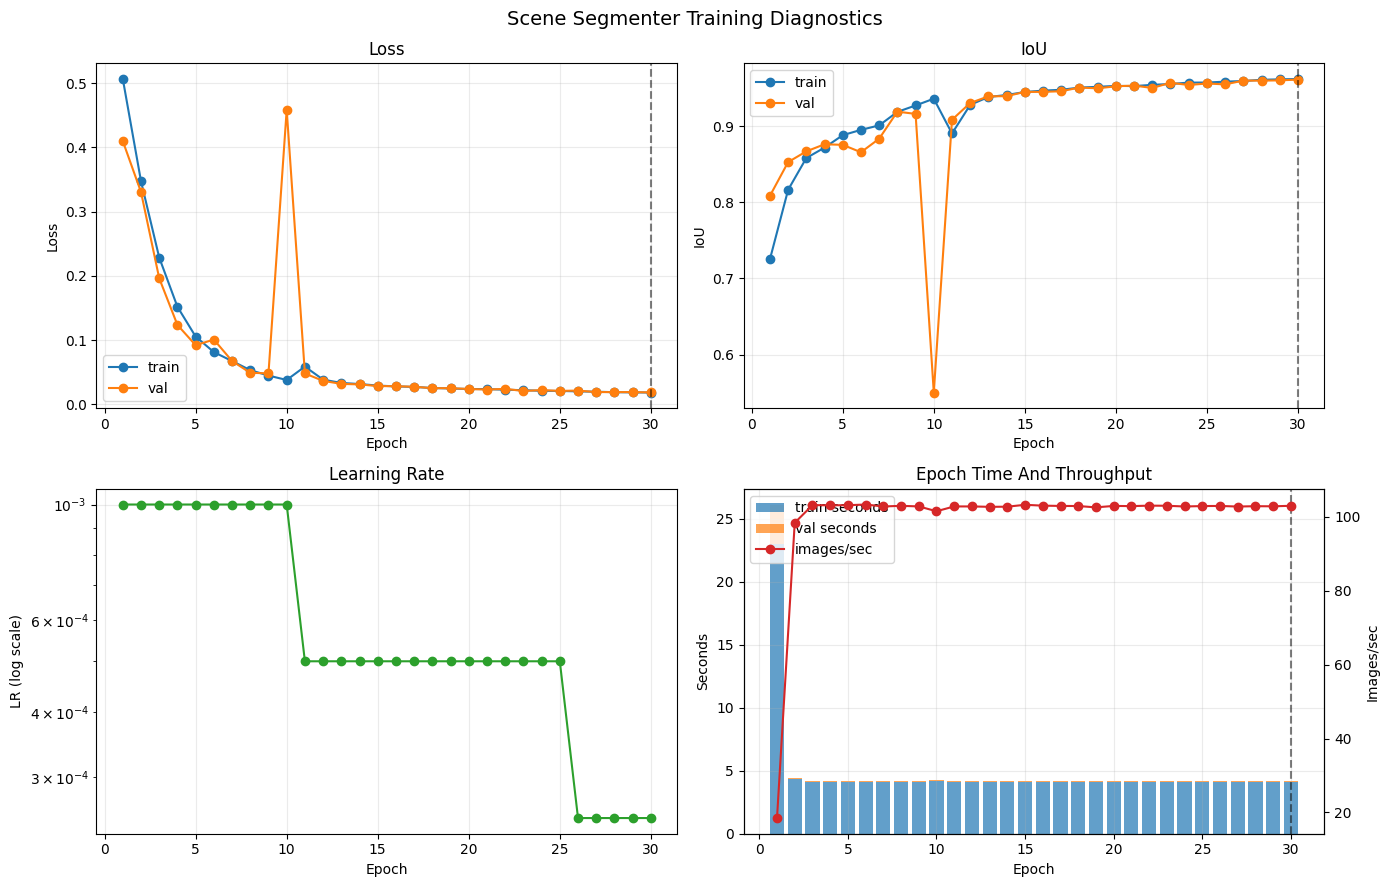

Best epoch: 30
Best val IoU: 0.9611
Epoch time at best epoch: 4.19s
Mean throughput: 99.92 img/s


In [9]:
if len(history["train_loss"]) == 0:
    raise RuntimeError("History is empty. Run the training cell first.")

epochs_x = np.arange(1, len(history["train_loss"]) + 1)
best_idx = int(np.argmax(history["val_iou"]))
best_epoch_plot = int(epochs_x[best_idx])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(epochs_x, history["train_loss"], marker="o", label="train")
axes[0, 0].plot(epochs_x, history["val_loss"], marker="o", label="val")
axes[0, 0].axvline(best_epoch_plot, color="k", linestyle="--", alpha=0.5)
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs_x, history["train_iou"], marker="o", label="train")
axes[0, 1].plot(epochs_x, history["val_iou"], marker="o", label="val")
axes[0, 1].axvline(best_epoch_plot, color="k", linestyle="--", alpha=0.5)
axes[0, 1].set_title("IoU")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("IoU")
axes[0, 1].legend()

axes[1, 0].plot(epochs_x, history["lr"], marker="o", color="tab:green")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Learning Rate")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("LR (log scale)")

if "train_seconds" in history and len(history["train_seconds"]) == len(epochs_x):
    train_seconds = np.array(history["train_seconds"])
    val_seconds = np.array(history["val_seconds"])
    axes[1, 1].bar(epochs_x, train_seconds, alpha=0.7, label="train seconds")
    axes[1, 1].bar(epochs_x, val_seconds, bottom=train_seconds, alpha=0.7, label="val seconds")
else:
    axes[1, 1].bar(epochs_x, history["epoch_seconds"], alpha=0.6, label="epoch seconds")

ax_speed = axes[1, 1].twinx()
ax_speed.plot(epochs_x, history["images_per_sec"], color="tab:red", marker="o", label="images/sec")
axes[1, 1].axvline(best_epoch_plot, color="k", linestyle="--", alpha=0.5)
axes[1, 1].set_title("Epoch Time And Throughput")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Seconds")
ax_speed.set_ylabel("Images/sec")

handles_1, labels_1 = axes[1, 1].get_legend_handles_labels()
handles_2, labels_2 = ax_speed.get_legend_handles_labels()
axes[1, 1].legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left")

for ax in axes.ravel():
    ax.grid(alpha=0.25)

plt.suptitle("Scene Segmenter Training Diagnostics", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Best epoch: {best_epoch_plot}")
print(f"Best val IoU: {history['val_iou'][best_idx]:.4f}")
print(f"Epoch time at best epoch: {history['epoch_seconds'][best_idx]:.2f}s")
print(f"Mean throughput: {np.mean(history['images_per_sec']):.2f} img/s")

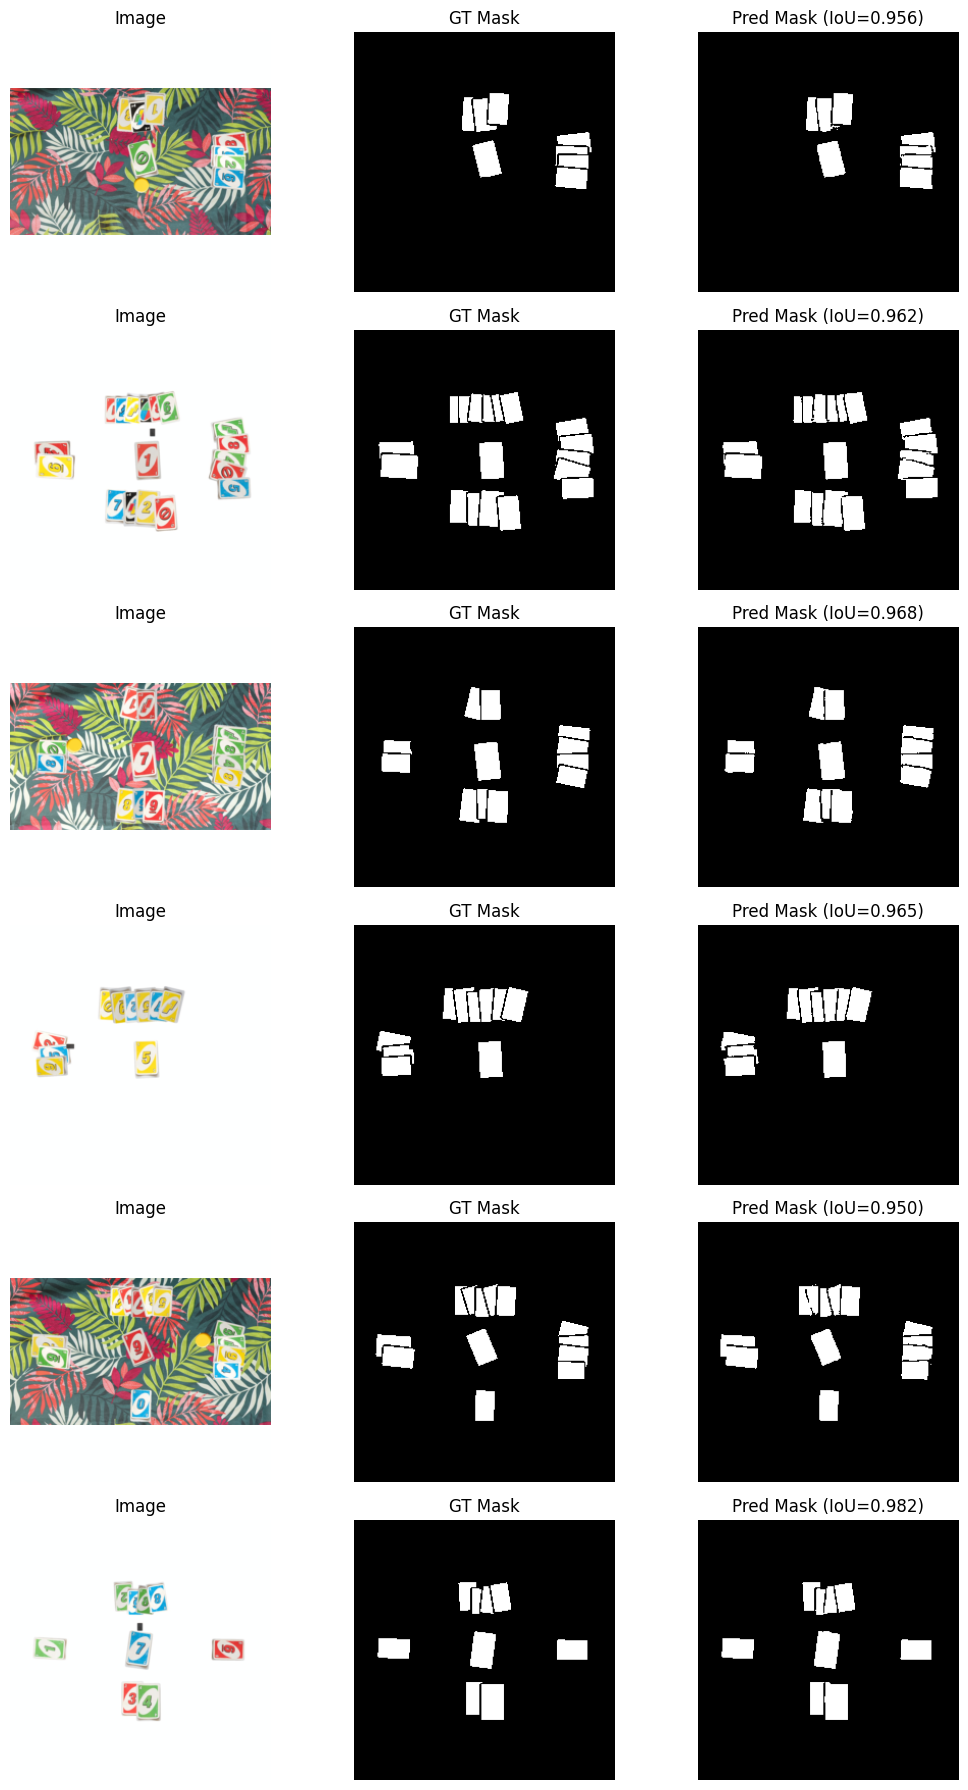

In [10]:
if scene_checkpoint.is_file():
    model.load_state_dict(torch.load(scene_checkpoint, map_location=device))
model.eval()

num_show = min(6, len(val_ds))
if num_show == 0:
    raise RuntimeError("Validation set is empty.")

indices = np.linspace(0, len(val_ds) - 1, num_show, dtype=int)
fig, axes = plt.subplots(num_show, 3, figsize=(11, 3 * num_show))

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

with torch.no_grad():
    for row, idx in enumerate(indices):
        img_t, mask_t = val_ds[int(idx)]
        logits = model(img_t.unsqueeze(0).to(device))
        pred = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.float32)

        gt = mask_t[0].cpu().numpy()
        inter = np.logical_and(pred_bin > 0.5, gt > 0.5).sum()
        union = np.logical_or(pred_bin > 0.5, gt > 0.5).sum()
        sample_iou = (inter + 1e-6) / (union + 1e-6)

        axes[row, 0].imshow(denormalize_image(img_t))
        axes[row, 0].set_title("Image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt, cmap="gray")
        axes[row, 1].set_title("GT Mask")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_bin, cmap="gray")
        axes[row, 2].set_title(f"Pred Mask (IoU={sample_iou:.3f})")
        axes[row, 2].axis("off")

plt.tight_layout()
plt.show()